# ETF 数据探索

查看已下载的精选池 ETF 数据。

In [1]:
import sys
sys.path.insert(0, 'data')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Heiti TC', 'STHeiti', 'Songti SC', 'sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False

from fetch_data import load_etf, load_close_matrix
from etf_universe import ETF_UNIVERSE, BROAD_ETFS, SECTOR_ETFS

## 1. 查看单只 ETF

In [2]:
df = load_etf('510300.SH')
print(f'沪深300ETF  共 {len(df)} 条，{df.trade_date.min().date()} → {df.trade_date.max().date()}')
df.tail(10)

沪深300ETF  共 2787 条，2015-01-05 → 2026-06-25


,trade_date,open,high,low,close,vol,amount
2777,2026-06-11,4.766,4.793,4.718,4.751,4160687.68,1.975530e+06
2778,2026-06-12,4.810,4.846,4.789,4.818,7808858.96,3.761995e+06
2779,2026-06-15,4.858,4.920,4.839,4.919,16233006.71,7.928405e+06
2780,2026-06-16,4.920,4.933,4.893,4.910,9085294.32,4.467242e+06
2781,2026-06-17,4.898,4.960,4.894,4.958,13911869.80,6.854309e+06
2782,2026-06-18,4.943,5.001,4.941,4.984,12933430.39,6.434057e+06
2783,2026-06-22,4.983,5.095,4.954,5.091,19131577.65,9.643147e+06
2784,2026-06-23,5.079,5.095,4.915,4.942,26173354.39,1.312128e+07
2785,2026-06-24,4.929,4.978,4.916,4.967,25906734.09,1.283932e+07
2786,2026-06-25,4.973,5.055,4.966,5.048,26406087.36,1.325289e+07


## 2. 价格走势图

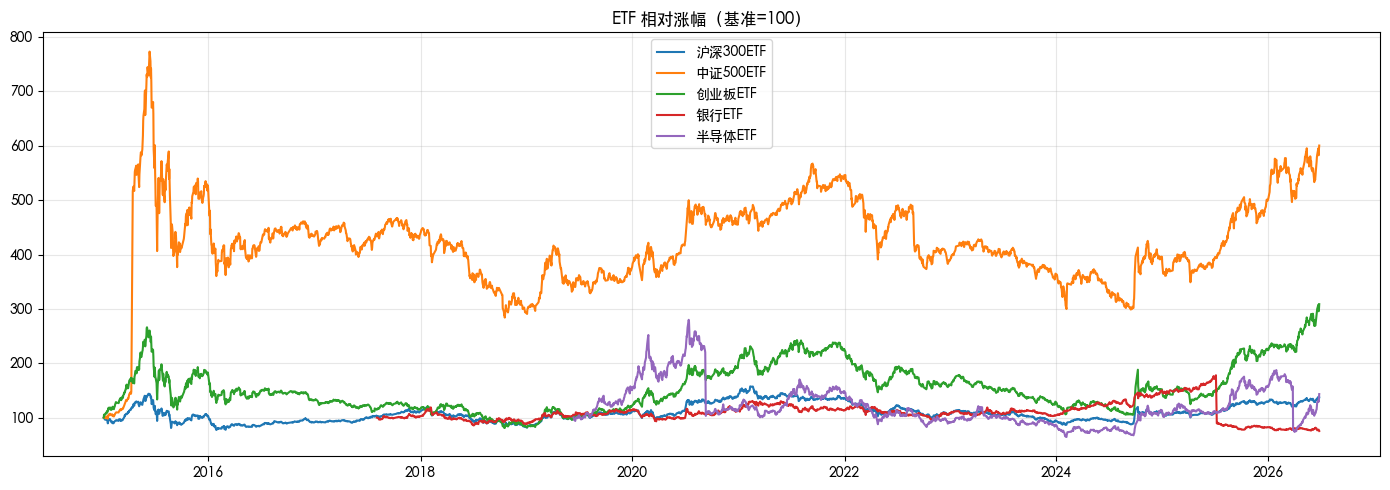

In [3]:
# 修改这里换标的
codes = ['510300.SH', '510500.SH', '159915.SZ', '512800.SH', '512760.SH']

fig, ax = plt.subplots(figsize=(14, 5))
for code in codes:
    d = load_etf(code).set_index('trade_date')['close']
    # 归一化到 100，方便比较相对涨幅
    ax.plot(d / d.iloc[0] * 100, label=ETF_UNIVERSE[code])

ax.set_title('ETF 相对涨幅（基准=100）')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 精选池概览：上市时间 + 数据条数

In [4]:
from fetch_data import DATA_DIR
import pathlib

rows = []
for code, name in ETF_UNIVERSE.items():
    path = DATA_DIR / f'{code}.parquet'
    if path.exists():
        d = pd.read_parquet(path, columns=['trade_date'])
        rows.append({
            '代码': code,
            '名称': name,
            '上市日期': d['trade_date'].min().date(),
            '最新日期': d['trade_date'].max().date(),
            '交易日数': len(d),
        })

summary = pd.DataFrame(rows).sort_values('上市日期')
summary

,代码,名称,上市日期,最新日期,交易日数
0,510300.SH,沪深300ETF,2015-01-05,2026-06-25,2787
37,159928.SZ,消费ETF,2015-01-05,2026-06-25,2787
36,510170.SH,上证综合ETF,2015-01-05,2026-06-25,2747
27,159931.SZ,地产ETF,2015-01-05,2026-06-25,2783
14,510050.SH,上证50ETF,2015-01-05,2026-06-25,2787
11,510180.SH,上证180ETF,2015-01-05,2026-06-25,2787
10,159905.SZ,中证100ETF,2015-01-05,2026-06-25,2787
8,510880.SH,红利ETF,2015-01-05,2026-06-25,2787
22,512010.SH,医疗卫生ETF,2015-01-05,2026-06-25,2785
6,159920.SZ,恒生ETF,2015-01-05,2026-06-25,2787


## 4. 收盘价矩阵（所有标的）

In [5]:
mat = load_close_matrix()
print(f'矩阵大小：{mat.shape}  ({mat.index.min().date()} → {mat.index.max().date()})')
mat.tail()

矩阵大小：(2787, 45)  (2015-01-05 → 2026-06-25)


,510300.SH,510500.SH,159915.SZ,588000.SH,159941.SZ,513500.SH,159920.SZ,513180.SH,510880.SH,512890.SH,...,512400.SH,510170.SH,159928.SZ,515700.SH,159997.SZ,159801.SZ,515220.SH,516950.SH,513050.SH,159611.SZ
trade_date,,,,,,,,,,,,,,,,,,,,,
2026-06-18,4.984,8.828,4.269,2.017,1.693,2.564,1.401,0.580,3.098,1.115,...,2.050,1.436,0.623,2.573,2.529,1.395,1.156,1.063,1.031,1.091
2026-06-22,5.091,9.007,4.379,2.056,1.686,2.565,1.407,0.582,3.125,1.114,...,2.155,1.495,0.627,2.636,2.565,1.444,1.181,1.082,1.029,1.095
2026-06-23,4.942,8.815,4.210,2.023,1.628,2.505,1.374,0.559,3.104,1.118,...,1.976,1.406,0.617,2.512,2.496,1.411,1.165,1.049,0.990,1.082
2026-06-24,4.967,8.985,4.258,2.096,1.644,2.523,1.387,0.570,3.048,1.099,...,1.980,1.420,0.608,2.555,2.616,1.491,1.129,1.039,1.002,1.060
2026-06-25,5.048,9.085,4.395,2.178,1.657,2.518,1.361,0.559,3.006,1.086,...,1.922,1.405,0.610,2.529,2.730,1.571,1.110,1.033,0.972,1.042


## 5. 相关性热力图（宽基 ETF）

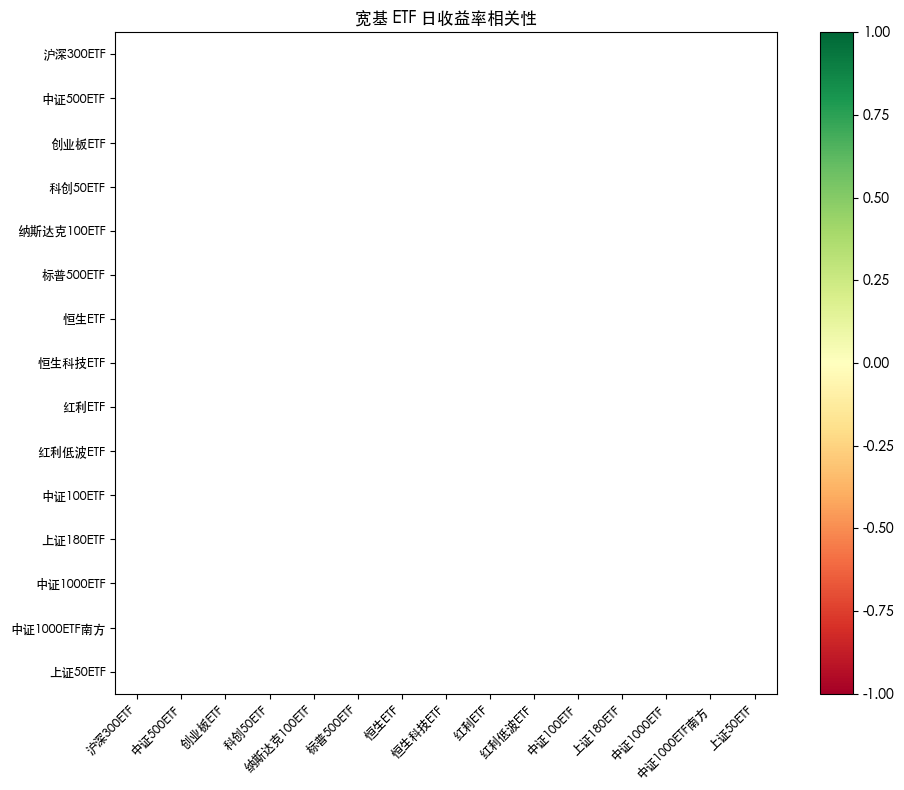

In [6]:
import numpy as np

broad_codes = list(BROAD_ETFS.keys())
broad_names = [BROAD_ETFS[c] for c in broad_codes]

# 只取有足够数据的标的（>500 个交易日）
sub = mat[broad_codes].dropna(thresh=500)
corr = sub.pct_change().corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(broad_codes)))
ax.set_yticks(range(len(broad_codes)))
ax.set_xticklabels(broad_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(broad_names, fontsize=9)
ax.set_title('宽基 ETF 日收益率相关性')

# 在格子里显示数值
for i in range(len(broad_codes)):
    for j in range(len(broad_codes)):
        val = corr.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()